# Imports

In [1]:
import torch
from torch import nn
from torch.nn import CrossEntropyLoss
from segmentation_models_pytorch.losses import DiceLoss
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from LabelMapper import LabelMapper
from RuralDataset import RuralDataset
from SegmentationModel import SegmentationModel
from Trainer import Trainer
from Evaluator import Evaluator
from ImageProcessor import ImageProcessor
torch.cuda.empty_cache()

# Configuration parameters

In [2]:
DATA_ROOT = 'train'
BATCH_SIZE = 8
LEARNING_RATE = 0.0001
NUM_EPOCHS = 10
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Device configuration

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


# Transforms initialization

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((272,512)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Dataset loading and splitting into training and validation sets

In [5]:
# Crea dataset separati con le rispettive trasformazioni
from torch.utils.data import random_split

# Applica la trasformazione di training e validazione ai rispettivi dataset
full_dataset = RuralDataset(root_dir=DATA_ROOT)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Suddividi il dataset in train e val
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Applica le trasformazioni ai sotto-dataset
# NOTA: random_split restituisce Subset, quindi bisogna settare la transform manualmente
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, num_workers=16, shuffle=False,
    pin_memory=True)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 695 samples, validating on 174 samples.


# Model initialization

In [6]:
model = SegmentationModel(NUM_CLASSES)
model.to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (dconv_down1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (dconv_down2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (dconv_down3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (dconv_down4): Sequential(
    (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)

# Loss Function and optimizer definition

In [7]:
#weights =[ 3.8332,  1.0790,  0.7218,  0.7481,  0.8233,  0.3108,  1.7673, 70.4379, 12.8048]
weights = Trainer.compute_class_weights(train_loader, num_classes=NUM_CLASSES)
# Definizione della funzione di loss combinata
cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))
dice_loss = DiceLoss(mode='multiclass')
def combined_loss(pred, target):
    return cross_entropy(pred, target) + dice_loss(pred, target)
criterion = combined_loss

C:\Users\thatsrux\AppData\Local\Temp\ipykernel_28532\4274843505.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cross_entropy = CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(device))


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trainer initialization and training


Starting training...

Epoch 1/10
Batch 1/87, Loss: 2.8864
Batch 2/87, Loss: 2.8897
Batch 3/87, Loss: 2.9990
Batch 4/87, Loss: 3.0054
Batch 5/87, Loss: 2.9979
Batch 6/87, Loss: 2.8859
Batch 7/87, Loss: 2.7849
Batch 8/87, Loss: 2.9978
Batch 9/87, Loss: 2.9992
Batch 10/87, Loss: 2.9913
Batch 11/87, Loss: 2.9996
Batch 12/87, Loss: 2.9946
Batch 13/87, Loss: 2.9868
Batch 14/87, Loss: 2.9823
Batch 15/87, Loss: 2.9659
Batch 16/87, Loss: 2.9405
Batch 17/87, Loss: 2.9287
Batch 18/87, Loss: 2.9383
Batch 19/87, Loss: 2.9923
Batch 20/87, Loss: 2.8862
Batch 21/87, Loss: 2.9933
Batch 22/87, Loss: 2.9810
Batch 23/87, Loss: 2.8372
Batch 24/87, Loss: 2.8024
Batch 25/87, Loss: 3.1110
Batch 26/87, Loss: 3.1000
Batch 27/87, Loss: 2.8004
Batch 28/87, Loss: 2.9165
Batch 29/87, Loss: 3.0298
Batch 30/87, Loss: 2.8618
Batch 31/87, Loss: 2.8198
Batch 32/87, Loss: 2.8548
Batch 33/87, Loss: 2.8534
Batch 34/87, Loss: 3.0444
Batch 35/87, Loss: 2.7641
Batch 36/87, Loss: 3.0830
Batch 37/87, Loss: 2.9586
Batch 38/87, 

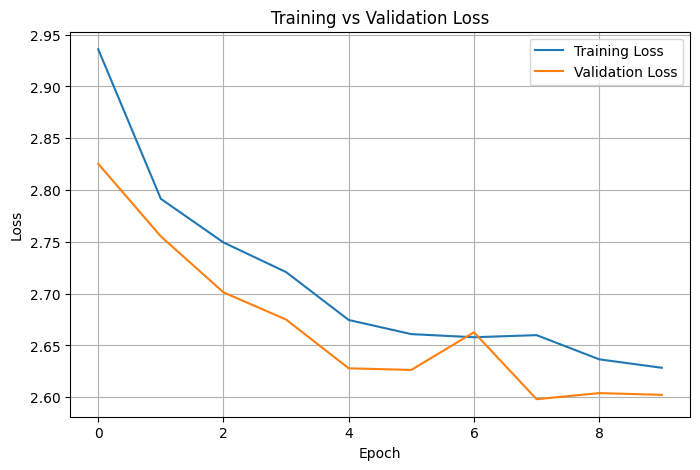

Training finished.


In [9]:
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

# Model evaluation

In [10]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

evaluator = Evaluator(model, val_loader, device)
metrics = evaluator.evaluate_classification_metrics()

# Example Predict

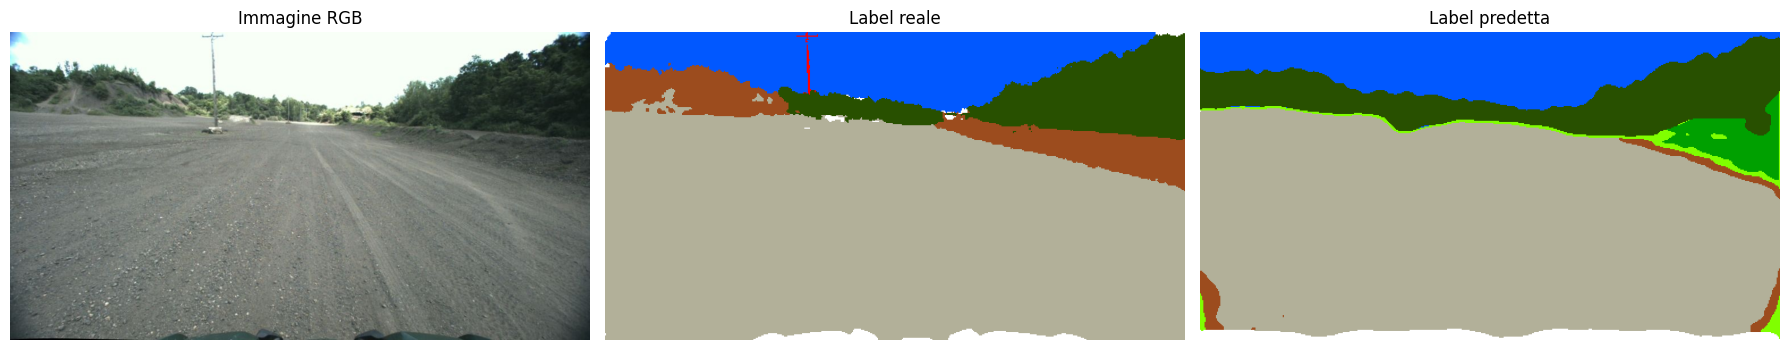

Pixel classificati correttamente: 122105 / 139264 (87.68%)
IoU medio sull'immagine: 0.3635
IoU per classe: [0.95524705 0.06359923 0.93576417 0.         0.58979921 0.
        nan 0.        ]


In [16]:
evaluator.predict_from_folder(folder_number = 429)

In [12]:
print(metrics.get('accuracy', 'N/A'))
print(metrics.get('f1_score', 'N/A'))
print(metrics.get('precision', 'N/A'))
print(metrics.get('recall', 'N/A'))

0.6085398624360844
N/A
0.40549115166673955
0.44988040849825656
